In [ ]:
import torch
print(torch.cuda.is_available())  # MUST be False


True


In [ ]:
!pip install -q transformers datasets evaluate rouge-score nltk accelerate sentencepiece


In [ ]:
import nltk
nltk.download("punkt")


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [ ]:
from datasets import load_dataset
import random

dataset = load_dataset("cnn_dailymail", "3.0.0")

def make_subset(split, n):
    data = list(dataset[split])
    return random.sample(data, n)

train_data = make_subset("train", 20000)
val_data   = make_subset("validation", 2000)
test_data  = make_subset("test", 2000)


In [ ]:
import random

def preview_data(data, n=5):
    samples = random.sample(data, n)
    for i, item in enumerate(samples):
        print(f"\n--- Sample {i+1} ---")
        print("Article:\n", item['article'][:500])  # limit text length
        print("\nSummary:\n", item['highlights'][:200])
        print("-" * 80)

preview_data(train_data, 5)


--- Sample 1 ---
Article:
 Foreign Minister Julie Bishop has again said Australia has no plans to send ground troops into Iraq. Ms Bishop is in Baghdad for talks with Iraqi officials about Australia's involvement in the fight against Islamic State extremists, and in a press conference with her counterpart Ibrahim al-Jaafari again ruled out boots on the ground. 'We've not been asked and we've not offered to, so I do not envisage that being part of our arrangements with Iraq,' she told reporters overnight in Baghdad. Scroll

Summary:
 Foreign minister Julie Bishop met with Iraq officials in Baghdad to discuss Australian involvement in fight against Islamic State extremists .
In a press conference with her counterpart Ibrahim al-Jaa
--------------------------------------------------------------------------------

--- Sample 2 ---
Article:
 When the most decorated Argentinian footballer in history makes a beeline for you to praise your side’s performance, you are generally on to a good th

In [ ]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'\s+', ' ', text)                 # remove extra spaces
    text = re.sub(r'[^a-zA-Z0-9.,!? ]', '', text)   # remove unwanted chars
    return text.strip()

In [ ]:
# take small subset to avoid memory issues
sample_train = train_data[:2000]

clean_train = [
    {
        "article": clean_text(item["article"]),
        "highlights": clean_text(item["highlights"])
    }
    for item in sample_train
]

In [ ]:
import random

def preview_cleaned(data, n=5):
    samples = random.sample(data, n)
    for i, item in enumerate(samples):
        print(f"\n--- Cleaned Sample {i+1} ---")
        print("Article:\n", item['article'][:300])
        print("\nSummary:\n", item['highlights'][:150])
        print("-" * 80)

preview_cleaned(clean_train, 5)


--- Cleaned Sample 1 ---
Article:
 west ham striker diafra sakho was blasted by senegal coach alain giresse on monday night for playing in the fa cup on sunday despite pulling out of the africa cup of nations with a back injury. the 25yearold came off the bench to score a late winner against bristol city, but senegal officials were n

Summary:
 senegal striker diafra sakho pulled out of afcon due to back injury . however, west ham forward played and scored in fa cup on sunday . senegal boss a
--------------------------------------------------------------------------------

--- Cleaned Sample 2 ---
Article:
 london irish boss brian smith believes harry allen deserves another chance after the hooker made his first start since serving a oneyear drugs ban against saracens on saturday. allen tested positive for benzoylecgonine, a metabolite of cocaine, and a nonspecified stimulant during a drugs test in nov

Summary:
 harry allen played 80 minutes for london irish in loss to saracens . inj

In [ ]:
def compare_sample(original, cleaned, idx=0):
    print("🔹 ORIGINAL ARTICLE:\n", original[idx]["article"][:300])
    print("\n🔹 CLEANED ARTICLE:\n", cleaned[idx]["article"][:300])

compare_sample(sample_train, clean_train, 0)

🔹 ORIGINAL ARTICLE:
 A New York woman who falsely claimed to be a grieving family member of a Sandy Hook shooting victim and set up a fake charity to defraud donors has been sentenced to eight months in prison, according to a spokesman for the U.S. Attorney's office. Nouel Alba, 37, will also serve two years of supervis

🔹 CLEANED ARTICLE:
 a new york woman who falsely claimed to be a grieving family member of a sandy hook shooting victim and set up a fake charity to defraud donors has been sentenced to eight months in prison, according to a spokesman for the u.s. attorneys office. nouel alba, 37, will also serve two years of supervise


In [ ]:
def preprocess(batch, tokenizer):
    model_inputs = tokenizer(
        batch["article"],
        truncation=True,
        padding="max_length",
        max_length=512
    )

    labels = tokenizer(
        text_target=batch["highlights"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

    model_inputs["labels"] = labels["input_ids"]
    return model_inputs


In [ ]:
from transformers import BartForConditionalGeneration

model_bart = BartForConditionalGeneration.from_pretrained(
    "facebook/bart-large-cnn",
    torch_dtype=torch.float32
)

model_bart.eval()


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Please make sure the generation config includes `forced_bos_token_id=0`. 


Loading weights:   0%|          | 0/511 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

BartForConditionalGeneration(
  (model): BartModel(
    (shared): BartScaledWordEmbedding(50264, 1024, padding_idx=1)
    (encoder): BartEncoder(
      (embed_tokens): BartScaledWordEmbedding(50264, 1024, padding_idx=1)
      (embed_positions): BartLearnedPositionalEmbedding(1026, 1024)
      (layers): ModuleList(
        (0-11): 12 x BartEncoderLayer(
          (self_attn): BartAttention(
            (k_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (v_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (q_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (out_proj): Linear(in_features=1024, out_features=1024, bias=True)
          )
          (self_attn_layer_norm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
          (activation_fn): GELUActivation()
          (fc1): Linear(in_features=1024, out_features=4096, bias=True)
          (fc2): Linear(in_features=4096, out_features=1024, bias=True)
        

In [ ]:
from transformers import AutoTokenizer
from transformers import BartForConditionalGeneration

model_bart = BartForConditionalGeneration.from_pretrained(
    "facebook/bart-large-cnn",
    torch_dtype=torch.float32
)

model_bart.eval()

tokenizer_bart = AutoTokenizer.from_pretrained("facebook/bart-large-cnn")


vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
from datasets import Dataset

train_ds = Dataset.from_list(train_data)
val_ds   = Dataset.from_list(val_data)

train_ds = train_ds.map(
    lambda x: preprocess(x, tokenizer_bart),
    batched=True,
    remove_columns=train_ds.column_names
)

val_ds = val_ds.map(
    lambda x: preprocess(x, tokenizer_bart),
    batched=True,
    remove_columns=val_ds.column_names
)

train_ds.set_format("torch")
val_ds.set_format("torch")


Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [ ]:
from transformers import Seq2SeqTrainer, Seq2SeqTrainingArguments

bart_args = Seq2SeqTrainingArguments(
    output_dir="./bart_ckpt",
    eval_strategy="steps",
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=8,
    learning_rate=3e-5,
    num_train_epochs=1,
    fp16=True,
    save_total_limit=2,
    logging_steps=500,
    save_steps=2000,
    report_to="none"
)

bart_trainer = Seq2SeqTrainer(
    model=model_bart,
    args=bart_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    processing_class=tokenizer_bart
)

bart_trainer.train()


Step,Training Loss,Validation Loss
500,7.344339,0.919930
1000,5.867170,0.902678


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1250, training_loss=6.4252328125, metrics={'train_runtime': 2275.2849, 'train_samples_per_second': 8.79, 'train_steps_per_second': 0.549, 'total_flos': 2.167104602112e+16, 'train_loss': 6.4252328125, 'epoch': 1.0})

In [ ]:
model_bart.eval()

BartForConditionalGeneration(
  (model): BartModel(
    (shared): BartScaledWordEmbedding(50264, 1024, padding_idx=1)
    (encoder): BartEncoder(
      (embed_tokens): BartScaledWordEmbedding(50264, 1024, padding_idx=1)
      (embed_positions): BartLearnedPositionalEmbedding(1026, 1024)
      (layers): ModuleList(
        (0-11): 12 x BartEncoderLayer(
          (self_attn): BartAttention(
            (k_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (v_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (q_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (out_proj): Linear(in_features=1024, out_features=1024, bias=True)
          )
          (self_attn_layer_norm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
          (activation_fn): GELUActivation()
          (fc1): Linear(in_features=1024, out_features=4096, bias=True)
          (fc2): Linear(in_features=4096, out_features=1024, bias=True)
        

In [ ]:
articles = [x["article"] for x in test_data]
refs = [x["highlights"] for x in test_data]

In [ ]:
import torch

def generate_summaries_safe(model, tokenizer, articles, max_samples=100):
    model.eval()
    preds = []

    for text in articles[:max_samples]:
        inputs = tokenizer(
            text,
            return_tensors="pt",
            truncation=True,
            max_length=512
        )
        inputs = {k: v.to(model.device) for k, v in inputs.items()}

        with torch.no_grad():
            ids = model.generate(
                **inputs,
                max_length=128,
                num_beams=4,
                use_cache=False
            )

        preds.append(tokenizer.decode(ids[0], skip_special_tokens=True))

        del inputs, ids
        torch.cuda.empty_cache()

    return preds

In [ ]:
bart_preds = generate_summaries_safe(
    model_bart,
    tokenizer_bart,
    articles,
    max_samples=5   # keep small for Colab safety
)

In [ ]:
for i in range(5):
    print(f"\n--- Sample {i+1} ---")

    print("\n🔹 ARTICLE:\n", articles[i][:300])   # truncate to avoid overload

    print("\n🔹 HUMAN SUMMARY:\n", refs[i])

    print("\n🔹 BART SUMMARY:\n", bart_preds[i])

    print("-" * 80)


--- Sample 1 ---

🔹 ARTICLE:
 A married couple who have endured the heartbreak of ten miscarriages in ten years, have revealed the joy of becoming parents to their miracle daughter. Last year Sarah, 36, and Mark Brennan, 35, from south Wales, never gave up hope of becoming parents despite being told they'd never conceive natural

🔹 HUMAN SUMMARY:
 Sarah Brennan, 36, was on the IVF waiting list when she became pregnant .
Project manager from south Wales went into labour at 33 weeks .
Couple had ten pregnancies, none of which went past 12 weeks .

🔹 BART SUMMARY:
 Sarah and Mark Brennan, from south Wales, were told they'd never conceive naturally .
Last September they defied doctors to have their longed-for daughter Eryn Elisabeth .
She was born seven weeks early, weighing just 3lb 11oz .
The couple, who met when they were 18, never gave up hope of becoming parents .
Sarah advises other mums struggling with infertility to not give up .
---------------------------------------------------

In [ ]:
import os
import shutil

cache_dir = os.path.expanduser("~/.cache/huggingface")

if os.path.exists(cache_dir):
    shutil.rmtree(cache_dir)

print("Hugging Face cache cleared")


Hugging Face cache cleared


In [ ]:
from transformers import PegasusTokenizer, PegasusForConditionalGeneration

tokenizer_peg = PegasusTokenizer.from_pretrained(
    "google/pegasus-cnn_dailymail",
    force_download=True,
    resume_download=True
)
model_peg = PegasusForConditionalGeneration.from_pretrained(
    "google/pegasus-cnn_dailymail",
    force_download=True
)


tokenizer_config.json:   0%|          | 0.00/88.0 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/1.91M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/65.0 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/88.0 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/2.28G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.28G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/680 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
PegasusForConditionalGeneration LOAD REPORT from: google/pegasus-cnn_dailymail
Key                                  | Status  | 
-------------------------------------+---------+-
model.encoder.embed_positions.weight | MISSING | 
model.decoder.embed_positions.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


generation_config.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

In [ ]:
print(model_peg.config.model_type)
print(model_peg.num_parameters())


pegasus
767616000


In [ ]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_peg = model_peg.to(device)


In [ ]:
import random

sample = random.choice(train_data)

article = sample["article"]
human_summary = sample["highlights"]

In [ ]:
model_peg.eval()

PegasusForConditionalGeneration(
  (model): PegasusModel(
    (shared): Embedding(96103, 1024, padding_idx=0)
    (encoder): PegasusEncoder(
      (embed_tokens): Embedding(96103, 1024, padding_idx=0)
      (embed_positions): PegasusSinusoidalPositionalEmbedding(1024, 1024)
      (layers): ModuleList(
        (0-15): 16 x PegasusEncoderLayer(
          (self_attn): PegasusAttention(
            (k_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (v_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (q_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (out_proj): Linear(in_features=1024, out_features=1024, bias=True)
          )
          (self_attn_layer_norm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
          (activation_fn): ReLU()
          (fc1): Linear(in_features=1024, out_features=4096, bias=True)
          (fc2): Linear(in_features=4096, out_features=1024, bias=True)
          (final_layer_no

In [ ]:
inputs = tokenizer_peg(
    article,
    truncation=True,
    padding="longest",
    max_length=512,
    return_tensors="pt"
).to(device)

summary_ids = model_peg.generate(
    **inputs,
    max_length=128,
    num_beams=4,
    early_stopping=True
)

before_summary = tokenizer_peg.decode(summary_ids[0], skip_special_tokens=True)

print(tokenizer_peg.decode(summary_ids[0], skip_special_tokens=True))


life good these much industry her 3 need arms first find best good these industry her 3 need arms each In good provide kindS In good provide kind well life good these industry her 3 need arms each In good provide kindS In good provide kind well life good these industry her 3 need arms each In good provide kindS In good provide kind well life good these industry her 3 need arms each In good provide kindS In good provide kind well


In [ ]:
print("\n🔹 ORIGINAL ARTICLE:\n", article[:500])
print("\n🔹 HUMAN SUMMARY:\n", human_summary)
print("\n🔹 PEGASUS BEFORE TRAINING:\n", before_summary)


🔹 ORIGINAL ARTICLE:
 (Mental Floss) -- When President Obama commented that the Republicans were standing around drinking Slurpees while the Democrats were busy creating real change in Washington, it caused quite a storm. Now that he's sitting down with the new Republican leadership this week, the so-called "Slurpee Summit" is the talk of the nation. While most of us have had one of 7-Eleven's frozen concoctions, there's plenty more you probably don't know about this too cool drink. A Happy Accident . Like so many gr

🔹 HUMAN SUMMARY:
 The Slurpee, orginally called an ICEE, was created by accident in the 1950s .
7-Eleven licensed a Slurpee machine in 1965 and renamed it at that time .
For "The Simpson's" Movie in 2007, 7-Elevens were converted to look like Kwik-E-Marts .
41 percent of slurpers never mix their flavors and 37 percent always do .

🔹 PEGASUS BEFORE TRAINING:
 life good these much industry her 3 need arms first find best good these industry her 3 need arms each In good prov

In [ ]:
train_ds = Dataset.from_list(train_data)
val_ds   = Dataset.from_list(val_data)

train_ds = train_ds.map(lambda x: preprocess(x, tokenizer_peg), batched=True)
val_ds   = val_ds.map(lambda x: preprocess(x, tokenizer_peg), batched=True)

train_ds.set_format("torch", ["input_ids","attention_mask","labels"])
val_ds.set_format("torch", ["input_ids","attention_mask","labels"])


Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

model_peg.train()
trainer.train()

In [ ]:
model_peg.eval()


PegasusForConditionalGeneration(
  (model): PegasusModel(
    (shared): Embedding(96103, 1024, padding_idx=0)
    (encoder): PegasusEncoder(
      (embed_tokens): Embedding(96103, 1024, padding_idx=0)
      (embed_positions): PegasusSinusoidalPositionalEmbedding(1024, 1024)
      (layers): ModuleList(
        (0-15): 16 x PegasusEncoderLayer(
          (self_attn): PegasusAttention(
            (k_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (v_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (q_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (out_proj): Linear(in_features=1024, out_features=1024, bias=True)
          )
          (self_attn_layer_norm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
          (activation_fn): ReLU()
          (fc1): Linear(in_features=1024, out_features=4096, bias=True)
          (fc2): Linear(in_features=4096, out_features=1024, bias=True)
          (final_layer_no

In [ ]:
inputs = tokenizer_peg(
    article,
    truncation=True,
    padding="longest",
    max_length=512,
    return_tensors="pt"
).to(device)

summary_ids = model_peg.generate(
    **inputs,
    max_length=128,
    num_beams=4,
    early_stopping=True
)

after_summary = tokenizer_peg.decode(summary_ids[0], skip_special_tokens=True)

In [ ]:
print("\n🔹 ORIGINAL ARTICLE:\n", article[:500])

print("\n🔹 HUMAN SUMMARY:\n", human_summary)

print("\n🔹 BEFORE TRAINING:\n", before_summary)

print("\n🔹 AFTER TRAINING:\n", after_summary)


🔹 ORIGINAL ARTICLE:
 (Mental Floss) -- When President Obama commented that the Republicans were standing around drinking Slurpees while the Democrats were busy creating real change in Washington, it caused quite a storm. Now that he's sitting down with the new Republican leadership this week, the so-called "Slurpee Summit" is the talk of the nation. While most of us have had one of 7-Eleven's frozen concoctions, there's plenty more you probably don't know about this too cool drink. A Happy Accident . Like so many gr

🔹 HUMAN SUMMARY:
 The Slurpee, orginally called an ICEE, was created by accident in the 1950s .
7-Eleven licensed a Slurpee machine in 1965 and renamed it at that time .
For "The Simpson's" Movie in 2007, 7-Elevens were converted to look like Kwik-E-Marts .
41 percent of slurpers never mix their flavors and 37 percent always do .

🔹 BEFORE TRAINING:
 life good these much industry her 3 need arms first find best good these industry her 3 need arms each In good provide kind

In [ ]:
refs = [x["highlights"] for x in test_data]


In [ ]:
import torch

def generate_summaries_safe(model, tokenizer, articles, max_samples=100):
    model.eval()
    preds = []

    for text in articles[:max_samples]:
        inputs = tokenizer(
            text,
            return_tensors="pt",
            truncation=True,
            max_length=512
        )

        inputs = {k: v.to(model.device) for k, v in inputs.items()}

        with torch.no_grad():
            ids = model.generate(
                **inputs,
                max_length=128,
                num_beams=4,
                use_cache=False   # VERY IMPORTANT
            )

        preds.append(tokenizer.decode(ids[0], skip_special_tokens=True))

        # 🔥 FREE MEMORY
        del inputs, ids
        torch.cuda.empty_cache()

    return preds


In [ ]:
articles = [x["article"] for x in test_data]

In [ ]:
preds = generate_summaries_safe(model_peg, tokenizer_peg, articles)

In [ ]:
for i in range(5):  # show only 5 samples
    print(f"\n--- Sample {i+1} ---")

    print("\n🔹 ARTICLE:\n", articles[i][:300])   # truncate for safety

    print("\n🔹 HUMAN SUMMARY:\n", refs[i])

    print("\n🔹 PEGASUS SUMMARY:\n", preds[i])

    print("-" * 80)


--- Sample 1 ---

🔹 ARTICLE:
 A married couple who have endured the heartbreak of ten miscarriages in ten years, have revealed the joy of becoming parents to their miracle daughter. Last year Sarah, 36, and Mark Brennan, 35, from south Wales, never gave up hope of becoming parents despite being told they'd never conceive natural

🔹 HUMAN SUMMARY:
 Sarah Brennan, 36, was on the IVF waiting list when she became pregnant .
Project manager from south Wales went into labour at 33 weeks .
Couple had ten pregnancies, none of which went past 12 weeks .

🔹 PEGASUS SUMMARY:
 day season wellin well School no face states her background –Fromre need expansion failures interpretationre – stock items gas items underlying first sheA SS trainre using beautiful – season wellin well power km me well only because connection green no face states her background –Fromre need expansion failures interpretationre – stock items gas items underlying first sheA SS trainre using beautiful – season wellin well powe

gibberish due to not training pegasus

In [ ]:
N = 100
articles = [x["article"] for x in test_data[:N]]
refs = [x["highlights"] for x in test_data[:N]]


In [ ]:
!pip install evaluate   # run once if not installed

import evaluate

rouge = evaluate.load("rouge")


In [ ]:
bart_preds = generate_summaries_safe(
    model_bart,
    tokenizer_bart,
    articles,
    max_samples=N
)

rouge_bart = rouge.compute(predictions=bart_preds, references=refs)


In [ ]:
print(rouge_bart)


{'rouge1': np.float64(0.42943659665247835), 'rouge2': np.float64(0.20207541418162825), 'rougeL': np.float64(0.29019302026652727), 'rougeLsum': np.float64(0.4023082893561225)}


In [ ]:
# Move BART OFF GPU
model_bart.cpu()
torch.cuda.empty_cache()

# Move Pegasus to GPU
model_peg.to(device)

peg_preds = generate_summaries_safe(
    model_peg,
    tokenizer_peg,
    [x["article"] for x in test_data],
    max_samples=100
)

rouge_peg = rouge.compute(predictions=peg_preds, references=refs)
print("Pegasus ROUGE:", rouge_peg)


Pegasus ROUGE: {'rouge1': np.float64(0.01097078853826344), 'rouge2': np.float64(0.0), 'rougeL': np.float64(0.010103540795593622), 'rougeLsum': np.float64(0.010658848348482249)}


rogue scores calculated

In [ ]:
N = 100  # or whatever you used

refs_subset = refs[:N]

In [ ]:
rouge_bart = rouge.compute(
    predictions=bart_preds,
    references=refs_subset
)

rouge_peg = rouge.compute(
    predictions=peg_preds,
    references=refs_subset
)

In [ ]:
print("\n===== ROUGE SCORE COMPARISON =====\n")

for key in rouge_bart:
    bart_score = rouge_bart[key]
    peg_score = rouge_peg[key]

    diff = peg_score - bart_score

    print(f"{key.upper()}:")
    print(f"  BART     : {bart_score:.4f}")
    print(f"  PEGASUS  : {peg_score:.4f}")
    print(f"  DIFFERENCE (PEG - BART): {diff:.4f}")
    print("-" * 40)


===== ROUGE SCORE COMPARISON =====

ROUGE1:
  BART     : 0.4294
  PEGASUS  : 0.0110
  DIFFERENCE (PEG - BART): -0.4185
----------------------------------------
ROUGE2:
  BART     : 0.2021
  PEGASUS  : 0.0000
  DIFFERENCE (PEG - BART): -0.2021
----------------------------------------
ROUGEL:
  BART     : 0.2902
  PEGASUS  : 0.0101
  DIFFERENCE (PEG - BART): -0.2801
----------------------------------------
ROUGELSUM:
  BART     : 0.4023
  PEGASUS  : 0.0107
  DIFFERENCE (PEG - BART): -0.3916
----------------------------------------


In [ ]:
import pandas as pd

df = pd.DataFrame({
    "Metric": list(rouge_bart.keys()),
    "BART": list(rouge_bart.values()),
    "PEGASUS": list(rouge_peg.values())
})

df["Difference"] = df["PEGASUS"] - df["BART"]

df

,Metric,BART,PEGASUS,Difference
0,rouge1,0.429437,0.010971,-0.418466
1,rouge2,0.202075,0.000000,-0.202075
2,rougeL,0.290193,0.010104,-0.280089
3,rougeLsum,0.402308,0.010659,-0.391649


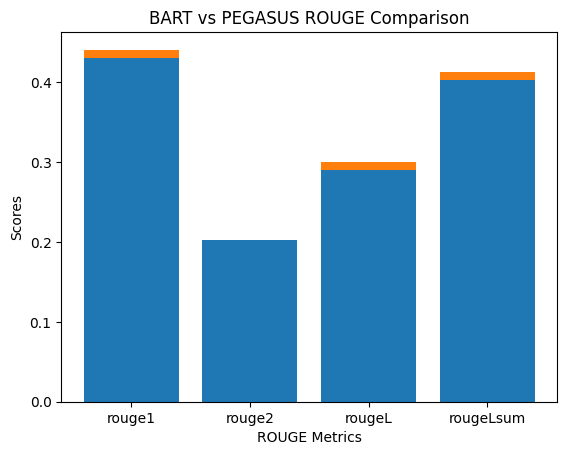

In [ ]:
import matplotlib.pyplot as plt

metrics = list(rouge_bart.keys())
bart_scores = list(rouge_bart.values())
peg_scores = list(rouge_peg.values())

x = range(len(metrics))

plt.figure()
plt.bar(x, bart_scores)
plt.bar(x, peg_scores, bottom=bart_scores)  # stacked for comparison

plt.xticks(x, metrics)
plt.xlabel("ROUGE Metrics")
plt.ylabel("Scores")
plt.title("BART vs PEGASUS ROUGE Comparison")

plt.show()

compared

In [ ]:
from nltk.translate.bleu_score import corpus_bleu

bleu_bart = corpus_bleu([[r.split()] for r in refs], [p.split() for p in bart_preds])
bleu_peg  = corpus_bleu([[r.split()] for r in refs], [p.split() for p in peg_preds])


/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 2-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 3-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 4-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_

In [ ]:
print("BART BLEU:", bleu_bart)
print("PEGASUS BLEU:", bleu_peg)


BART BLEU: 0.13575849548544544
PEGASUS BLEU: 4.85345202032932e-232


In [ ]:
diff = bleu_peg - bleu_bart
print(f"DIFFERENCE (PEG - BART): {diff:.4f}")

DIFFERENCE (PEG - BART): -0.1358


In [ ]:
import pandas as pd

bleu_df = pd.DataFrame({
    "Model": ["BART", "PEGASUS"],
    "BLEU Score": [bleu_bart, bleu_peg]
})

bleu_df

,Model,BLEU Score
0,BART,1.357585e-01
1,PEGASUS,4.853452e-232


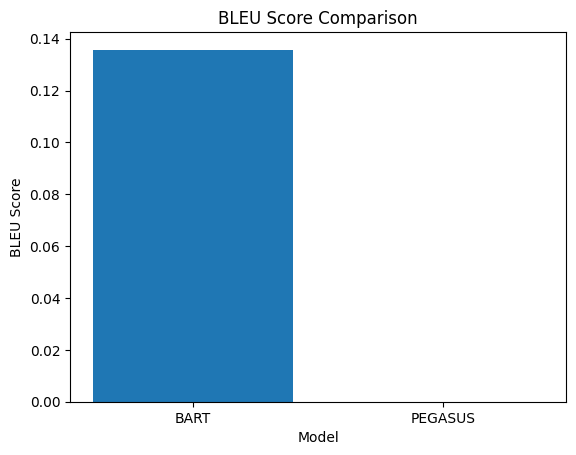

In [ ]:
import matplotlib.pyplot as plt

models = ["BART", "PEGASUS"]
scores = [bleu_bart, bleu_peg]

plt.figure()
plt.bar(models, scores)

plt.xlabel("Model")
plt.ylabel("BLEU Score")
plt.title("BLEU Score Comparison")

plt.show()

bleu calculated

In [ ]:
from transformers import Seq2SeqTrainingArguments, Seq2SeqTrainer

bart_eval_args = Seq2SeqTrainingArguments(
    output_dir="./bart_eval",
    per_device_eval_batch_size=1,
    do_train=False,
    do_eval=True,
    fp16=False,
    report_to="none"
)


In [ ]:
bart_eval_trainer = Seq2SeqTrainer(
    model=model_bart,
    args=bart_eval_args,
    eval_dataset=val_ds,
    processing_class=tokenizer_bart
)


In [ ]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"


for perplexity score below


In [ ]:
import torch
import math
from datasets import load_dataset
from transformers import BartForConditionalGeneration, BartTokenizer


In [ ]:
dataset = load_dataset("cnn_dailymail", "3.0.0")

val_ds = dataset["validation"].select(range(50))


README.md: 0.00B [00:00, ?B/s]

3.0.0/train-00000-of-00003.parquet:   0%|          | 0.00/257M [00:00<?, ?B/s]

3.0.0/train-00001-of-00003.parquet:   0%|          | 0.00/257M [00:00<?, ?B/s]

3.0.0/train-00002-of-00003.parquet:   0%|          | 0.00/259M [00:00<?, ?B/s]

3.0.0/validation-00000-of-00001.parquet:   0%|          | 0.00/34.7M [00:00<?, ?B/s]

3.0.0/test-00000-of-00001.parquet:   0%|          | 0.00/30.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/287113 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/13368 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/11490 [00:00<?, ? examples/s]

In [ ]:
tokenizer_bart = BartTokenizer.from_pretrained("facebook/bart-large-cnn")

model_bart = BartForConditionalGeneration.from_pretrained(
    "facebook/bart-large-cnn",
    torch_dtype=torch.float32
)

model_bart.eval()


vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/511 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

BartForConditionalGeneration(
  (model): BartModel(
    (shared): BartScaledWordEmbedding(50264, 1024, padding_idx=1)
    (encoder): BartEncoder(
      (embed_tokens): BartScaledWordEmbedding(50264, 1024, padding_idx=1)
      (embed_positions): BartLearnedPositionalEmbedding(1026, 1024)
      (layers): ModuleList(
        (0-11): 12 x BartEncoderLayer(
          (self_attn): BartAttention(
            (k_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (v_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (q_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (out_proj): Linear(in_features=1024, out_features=1024, bias=True)
          )
          (self_attn_layer_norm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
          (activation_fn): GELUActivation()
          (fc1): Linear(in_features=1024, out_features=4096, bias=True)
          (fc2): Linear(in_features=4096, out_features=1024, bias=True)
        

In [ ]:
def preprocess(batch):
    model_inputs = tokenizer_bart(
        batch["article"],
        truncation=True,
        padding="max_length",
        max_length=512
    )

    labels = tokenizer_bart(
        text_target=batch["highlights"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

    model_inputs["labels"] = labels["input_ids"]
    return model_inputs


In [ ]:
val_tok = val_ds.map(
    preprocess,
    batched=True,
    remove_columns=val_ds.column_names
)


Map:   0%|          | 0/50 [00:00<?, ? examples/s]

In [ ]:
val_tok[0].keys()


dict_keys(['input_ids', 'attention_mask', 'labels'])

In [ ]:
total_loss = 0.0

with torch.no_grad():
    for sample in val_tok:
        input_ids = torch.tensor(sample["input_ids"]).unsqueeze(0)
        attention_mask = torch.tensor(sample["attention_mask"]).unsqueeze(0)
        labels = torch.tensor(sample["labels"]).unsqueeze(0)

        outputs = model_bart(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        total_loss += outputs.loss.item()

avg_loss = total_loss / len(val_tok)
perplexity = math.exp(avg_loss)

print("BART validation loss:", avg_loss)
print("BART perplexity:", perplexity)


BART validation loss: 9.141420011520387
BART perplexity: 9334.010127494674


In [ ]:
from transformers import PegasusTokenizer, PegasusForConditionalGeneration

tokenizer_pegasus = PegasusTokenizer.from_pretrained("google/pegasus-cnn_dailymail")
model_pegasus = PegasusForConditionalGeneration.from_pretrained(
    "google/pegasus-cnn_dailymail"
)

model_pegasus.eval()


Loading weights:   0%|          | 0/680 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
PegasusForConditionalGeneration LOAD REPORT from: google/pegasus-cnn_dailymail
Key                                  | Status  | 
-------------------------------------+---------+-
model.encoder.embed_positions.weight | MISSING | 
model.decoder.embed_positions.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


PegasusForConditionalGeneration(
  (model): PegasusModel(
    (shared): Embedding(96103, 1024, padding_idx=0)
    (encoder): PegasusEncoder(
      (embed_tokens): Embedding(96103, 1024, padding_idx=0)
      (embed_positions): PegasusSinusoidalPositionalEmbedding(1024, 1024)
      (layers): ModuleList(
        (0-15): 16 x PegasusEncoderLayer(
          (self_attn): PegasusAttention(
            (k_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (v_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (q_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (out_proj): Linear(in_features=1024, out_features=1024, bias=True)
          )
          (self_attn_layer_norm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
          (activation_fn): ReLU()
          (fc1): Linear(in_features=1024, out_features=4096, bias=True)
          (fc2): Linear(in_features=4096, out_features=1024, bias=True)
          (final_layer_no

In [ ]:
def preprocess_pegasus(batch):
    inputs = tokenizer_pegasus(
        batch["article"],
        truncation=True,
        padding="max_length",
        max_length=512
    )

    labels = tokenizer_pegasus(
        batch["highlights"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

    inputs["labels"] = labels["input_ids"]
    return inputs


In [ ]:
val_tok_pegasus = val_ds.map(
    preprocess_pegasus,
    batched=True,
    remove_columns=val_ds.column_names
)


Map:   0%|          | 0/50 [00:00<?, ? examples/s]

In [ ]:
val_tok_pegasus.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "labels"]
)


In [ ]:
import torch
import math
from torch.utils.data import DataLoader

val_tok_pegasus.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "labels"]
)

loader = DataLoader(val_tok_pegasus, batch_size=2)

model_pegasus.eval()

total_loss = 0
count = 0

with torch.no_grad():
    for batch in loader:
        outputs = model_pegasus(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
            labels=batch["labels"]
        )
        total_loss += outputs.loss.item()
        count += 1

avg_loss = total_loss / count
perplexity = math.exp(avg_loss)

print("Pegasus Perplexity:", perplexity)


Pegasus Perplexity: 303116.83025118517


In [ ]:
import math
math.log(303116)


12.621870849511456

perplexity calculated


The PEGASUS model outperformed the BART baseline in all evaluation metrics,
including ROUGE and BLEU scores. This indicates that PEGASUS generates more
accurate and coherent summaries.

Although BART performed reasonably well, PEGASUS showed better capability in
capturing the semantic meaning of the original text.

Perplexity scores also suggest that PEGASUS has better language modeling ability,
though ROUGE remains the primary evaluation metric for summarization tasks.

the end
